# Chapter 4: The Bathtub Most People Misread

*Systems Thinking with AI* by Jason Karpeles

A level and a rate have different units, and reading one off the other is the error.

**Goal.** Four small tubs built from the chapter's own tables. Change one value at a time and watch the level follow the net flow, the step length convert a rate into an amount, two tubs leak water when updated in the wrong order, and a floor show up as a conservation residual.

**Demonstrations**

1. A falling inflow can still fill the tub
2. The step length turns a rate into an amount
3. Read every flow, then write every stock
4. A floor is a claim, and conservation can see it

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/04-bathtub/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/04-bathtub/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_04_stock_and_flow/code/validate_number.py`

In [2]:
%%module chapters.chapter_04_stock_and_flow.code.validate_number
import math


def validate_number(value: float, name: str) -> None:
    """Reject non-numeric or non-finite values used by the teaching functions."""
    if type(value) not in (int, float) or not math.isfinite(float(value)):
        raise ValueError(f"{name} must be a finite number")


`chapters/chapter_04_stock_and_flow/code/stock.py`

In [3]:
%%module chapters.chapter_04_stock_and_flow.code.stock
"""One stock, its flows, and the invariants that decide whether a path is readable.

The stock is the level. The flows are the rates that change it. Reading the level
off the inflow is the error this chapter exists to prevent.
"""

from .validate_number import validate_number


def net_flow(inflow: float, outflow: float) -> float:
    """Return the rate at which the stock changes: inflow minus outflow."""
    validate_number(inflow, "inflow")
    validate_number(outflow, "outflow")
    return inflow - outflow


def advance_stock(stock: float, inflow: float, outflow: float, dt: float) -> float:
    """Advance one stock by its net flow over one time step."""
    validate_number(stock, "stock")
    validate_number(dt, "dt")
    if dt < 0:
        raise ValueError("dt must be non-negative")
    return stock + dt * net_flow(inflow, outflow)


def integrate(
    initial: float, inflows: list[float], outflows: list[float], dt: float = 1.0
) -> list[float]:
    """Rebuild the whole path of a stock from its initial level and its flow history."""
    validate_number(initial, "initial")
    validate_number(dt, "dt")
    if dt <= 0:
        raise ValueError("dt must be positive")
    if len(inflows) != len(outflows):
        raise ValueError("inflows and outflows must have the same length")
    if not inflows:
        raise ValueError("flow history must not be empty")
    path = [float(initial)]
    for inflow, outflow in zip(inflows, outflows, strict=True):
        path.append(advance_stock(path[-1], inflow, outflow, dt))
    return path


def conservation_error(
    path: list[float], inflows: list[float], outflows: list[float], dt: float = 1.0
) -> float:
    """Compare the endpoint stock change with total recorded net flow.

    Zero establishes endpoint consistency, not path accuracy or completeness of
    gross flows. Intermediate errors or omitted offsetting flows can cancel.
    """
    if len(path) != len(inflows) + 1:
        raise ValueError("path must hold one more value than the flow history")
    if len(inflows) != len(outflows):
        raise ValueError("inflows and outflows must have the same length")
    validate_number(dt, "dt")
    accumulated = sum(
        dt * net_flow(inflow, outflow) for inflow, outflow in zip(inflows, outflows, strict=True)
    )
    return (path[-1] - path[0]) - accumulated


def apply_floor(stock: float, floor: float = 0.0) -> float:
    """Hold a stock at a physical bound. A tank cannot drain past empty."""
    validate_number(stock, "stock")
    validate_number(floor, "floor")
    return stock if stock > floor else floor


def interval_residuals(
    path: list[float], inflows: list[float], outflows: list[float], dt: float = 1.0
) -> list[float]:
    """Compare each interval's stock change with its recorded net flow.

    These detect path errors hidden by the endpoint check. Zero still cannot
    establish completeness when unrecorded inflows and outflows cancel.
    """
    if len(path) != len(inflows) + 1 or len(inflows) != len(outflows):
        raise ValueError("path and flow histories must have compatible lengths")
    validate_number(dt, "dt")
    if dt <= 0:
        raise ValueError("dt must be positive")
    for stock in path:
        validate_number(stock, "stock")
    return [
        path[i + 1] - path[i] - dt * net_flow(inflow, outflow)
        for i, (inflow, outflow) in enumerate(zip(inflows, outflows, strict=True))
    ]


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [4]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [5]:
"""Chapter 4 reader: the bathtub, read as a level and two rates.

Every number comes from the Chapter 4 pack (integrate, advance_stock,
conservation_error, apply_floor) so the reader, the pack and the book agree.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, label_point, new_figure, signed

from chapters.chapter_04_stock_and_flow.code.stock import (
    advance_stock,
    apply_floor,
    conservation_error,
    integrate,
    net_flow,
)

EQ_STOCK = "stock(t + dt) = stock(t) + dt * (inflow - outflow)"
EQ_FLOOR = "apply_floor(stock, floor=0.0)"

FALLING = [10.0, 9.0, 8.0, 7.0, 6.0]
RISING = [5.0, 6.0, 7.0, 8.0, 9.0]


def _arith(values):
    return " + ".join(signed(v, 0) for v in values)


# Demonstration 1: a falling inflow does not settle the direction of the level.

def rate_versus_level(inflow_shape="falling", outflow=4.0):
    inflows = FALLING if inflow_shape == "falling" else RISING
    outflows = [float(outflow)] * len(inflows)
    path = integrate(initial=50.0, inflows=inflows, outflows=outflows)
    nets = [net_flow(i, o) for i, o in zip(inflows, outflows)]
    minutes = np.arange(0, 6)

    fig, (top, bottom) = new_figure(ncols=2)
    steps = np.arange(1, 6)
    top.plot(steps, inflows, marker="o", color=PALETTE["teal"])
    top.plot(steps, outflows, marker="s", color=PALETTE["terracotta"])
    label_point(top, 5, inflows[-1], "Inflow", color=PALETTE["teal"], dx=-4, dy=8, ha="right")
    label_point(top, 1, outflows[0], "Outflow", color=PALETTE["terracotta"], dx=4, dy=8)
    top.set_xlim(0.6, 5.4)
    top.set_ylim(0, 13)
    top.set_xticks(steps)
    top.set_xlabel("Minute")
    top.set_ylabel("Rate (litres per minute)")
    top.set_title("The rates", fontsize=11.5)

    bottom.plot(minutes, path, marker="o", color=PALETTE["navy"])
    for m, level in zip(minutes, path):
        bottom.annotate(fmt(level, 0), (m, level), xytext=(0, 7), textcoords="offset points",
                        ha="center", fontsize=10.5, color=PALETTE["navy"])
    bottom.set_xlim(-0.4, 5.4)
    bottom.set_ylim(20, 85)
    bottom.set_xticks(minutes)
    bottom.set_xlabel("Minute")
    bottom.set_ylabel("Water in the tub (litres)")
    bottom.set_title("The level", fontsize=11.5)

    change = path[-1] - path[0]
    if change > 0:
        verdict = "The tub gained water"
    elif change < 0:
        verdict = "The tub lost water"
    else:
        verdict = "The tub ended where it started"
    metrics = {
        "Inflow direction": "falling every minute" if inflow_shape == "falling" else "rising every minute",
        "Net flow by minute (l/min)": ", ".join(signed(n, 0) for n in nets),
        "Level after 5 minutes (l)": fmt(path[-1], 0),
        "Change in level (l)": signed(change, 0),
    }
    interpretation = (
        f"Each minute adds inflow minus outflow. The net flows are {_arith(nets)}, so the level is "
        f"50 + {_arith(nets)} = {fmt(path[-1], 0)} litres. {verdict}, by {fmt(abs(change), 0)} litres, "
        f"while the inflow was {inflow_shape}. The direction of the level follows the sign of the net "
        f"flow, not the direction of either rate."
    )
    alt = (
        f"Left panel: the inflow {inflow_shape} from {fmt(inflows[0], 0)} to {fmt(inflows[-1], 0)} litres "
        f"per minute against a flat outflow of {fmt(outflow, 0)}. Right panel: the level moves from 50 to "
        f"{fmt(path[-1], 0)} litres."
    )
    return fig, metrics, interpretation, alt


# Demonstration 2: dt converts a rate into an amount.

def step_length(dt=1.0, keep_dt="kept"):
    inflow, outflow, minutes = 10.0, 4.0, 5.0
    steps = int(round(minutes / dt))
    times = [0.0]
    right = [50.0]
    wrong = [50.0]
    for k in range(steps):
        times.append((k + 1) * dt)
        right.append(advance_stock(right[-1], inflow, outflow, dt))
        wrong.append(advance_stock(wrong[-1], inflow, outflow, 1.0))
    shown = right if keep_dt == "kept" else wrong

    fig, ax = new_figure()
    ax.plot(times, right, marker="o", color=PALETTE["navy"])
    label_point(ax, times[-1], right[-1], f"dt kept: {fmt(right[-1], 0)} l", color=PALETTE["navy"],
                dx=-6, dy=-14, ha="right", va="top")
    if keep_dt == "dropped":
        ax.plot(times, wrong, marker="s", linestyle="dashed", color=PALETTE["terracotta"])
        label_point(ax, times[-1], wrong[-1], f"dt dropped: {fmt(wrong[-1], 0)} l",
                    color=PALETTE["terracotta"], dx=-6, dy=6, ha="right")
    ax.set_xlim(-0.2, 5.4)
    ax.set_ylim(40, 200)
    ax.set_xlabel("Time (minutes)")
    ax.set_ylabel("Water in the tub (litres)")

    gain_per_step = dt * net_flow(inflow, outflow) if keep_dt == "kept" else net_flow(inflow, outflow)
    metrics = {
        "Step length dt (minutes)": fmt(dt, 2),
        "Steps in 5 minutes": steps,
        "Litres added per step": fmt(gain_per_step, 1),
        "Level after 5 minutes (l)": fmt(shown[-1], 0),
    }
    if keep_dt == "kept":
        interpretation = (
            f"With dt = {fmt(dt, 2)}, each step adds {fmt(dt, 2)} x (10 - 4) = {fmt(gain_per_step, 1)} litres. "
            f"{steps} steps x {fmt(gain_per_step, 1)} = {fmt(steps * gain_per_step, 0)}, so the tub ends at "
            f"50 + {fmt(steps * gain_per_step, 0)} = {fmt(right[-1], 0)} litres whatever the step length."
        )
    else:
        interpretation = (
            f"Dropping dt adds the rate itself, 10 - 4 = 6, at every step. {steps} steps x 6 = "
            f"{fmt(steps * 6, 0)}, so the tub reads 50 + {fmt(steps * 6, 0)} = {fmt(wrong[-1], 0)} litres "
            f"instead of {fmt(right[-1], 0)}. Litres per minute were added to litres, and the answer now "
            f"depends on the step length."
        )
    return fig, metrics, interpretation


# Demonstration 3: two tubs in series, flows first or stocks first.

def two_tubs(drain_fraction=0.5, order="flows first"):
    a, b = 100.0, 0.0
    if order == "flows first":
        flow = drain_fraction * a
        a_next = advance_stock(a, 0.0, flow, 1.0)
        b_next = advance_stock(b, flow, 0.0, 1.0)
        flow_into_b = flow
    else:
        flow_out_of_a = drain_fraction * a
        a_next = advance_stock(a, 0.0, flow_out_of_a, 1.0)
        flow_into_b = drain_fraction * a_next
        b_next = advance_stock(b, flow_into_b, 0.0, 1.0)
    total = a_next + b_next
    leak = total - (a + b)

    fig, ax = new_figure()
    xs = np.array([0, 1])
    width = 0.34
    ax.bar(xs - width / 2, [a, b], width, color=PALETTE["light"], edgecolor=PALETTE["grey"])
    ax.bar(xs + width / 2, [a_next, b_next], width, color=PALETTE["navy"])
    for x, before, after in zip(xs, [a, b], [a_next, b_next]):
        ax.annotate(fmt(before, 0), (x - width / 2, before), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=10.5)
        ax.annotate(fmt(after, 0), (x + width / 2, after), xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=10.5, color=PALETTE["navy"])
    ax.set_xticks(xs, ["Tub A", "Tub B"])
    ax.set_ylim(0, 125)
    ax.set_xlabel("Stock (grey: time t, blue: one step later)")
    ax.set_ylabel("Water (litres)")

    metrics = {
        "Update order": order,
        "Flow out of A (l)": fmt(drain_fraction * a, 0),
        "Flow into B (l)": fmt(flow_into_b, 0),
        "A + B after one step (l)": fmt(total, 0),
        "Water created or lost (l)": signed(leak, 0),
    }
    if order == "flows first":
        interpretation = (
            f"Read the flow from A at time t: {fmt(drain_fraction, 1)} x 100 = {fmt(flow_into_b, 0)} litres. "
            f"Then A = 100 - {fmt(flow_into_b, 0)} = {fmt(a_next, 0)} and B = 0 + {fmt(flow_into_b, 0)} = "
            f"{fmt(b_next, 0)}. Together {fmt(total, 0)} litres, the same 100 the step began with."
        )
    else:
        interpretation = (
            f"A drains {fmt(drain_fraction, 1)} x 100 = {fmt(drain_fraction * a, 0)} litres to {fmt(a_next, 0)}, "
            f"then B's inflow is read from A's new level: {fmt(drain_fraction, 1)} x {fmt(a_next, 0)} = "
            f"{fmt(flow_into_b, 0)}. A + B = {fmt(a_next, 0)} + {fmt(b_next, 0)} = {fmt(total, 0)}, so "
            f"{fmt(abs(leak), 0)} litres vanished inside one step because the change in A reached B too soon."
        )
    return fig, metrics, interpretation


# Demonstration 4: a floor is a claim, and it shows up in the conservation check.

def floor_claim(outflow=9.0, floor="applied"):
    inflows = [5.0] * 5
    outflows = [float(outflow)] * 5
    raw = integrate(initial=10.0, inflows=inflows, outflows=outflows)
    if floor == "applied":
        path = [10.0]
        for i, o in zip(inflows, outflows):
            path.append(apply_floor(advance_stock(path[-1], i, o, 1.0), floor=0.0))
    else:
        path = raw
    residual = conservation_error(path, inflows, outflows)

    fig, ax = new_figure()
    minutes = np.arange(0, 6)
    ax.axhline(0, color=PALETTE["grey"], linewidth=1.2)
    ax.plot(minutes, path, marker="o", color=PALETTE["navy"])
    for m, level in zip(minutes, path):
        ax.annotate(fmt(level, 0), (m, level), xytext=(0, 7), textcoords="offset points",
                    ha="center", fontsize=10.5, color=PALETTE["navy"])
    ax.set_xlim(-0.4, 5.4)
    ax.set_ylim(-40, 25)
    ax.set_xlabel("Minute")
    ax.set_ylabel("Stock (litres or currency)")

    net = 5.0 - float(outflow)
    metrics = {
        "Floor at zero": floor,
        "Net flow per minute": signed(net, 0),
        "Stock after 5 minutes": fmt(path[-1], 0),
        "Conservation residual": signed(residual, 0),
    }
    expected = 5 * net
    change = path[-1] - path[0]
    tail = (
        "The stock record and the flow record agree."
        if abs(residual) < 1e-9
        else "The floor removed a deficit the flows still record, so a reader who checks conservation finds it."
    )
    interpretation = (
        f"The flows say the stock should change by 5 x (5 - {fmt(outflow, 0)}) = {signed(expected, 0)}. "
        f"The path changed by {fmt(path[-1], 0)} - 10 = {signed(change, 0)}. Residual = {signed(change, 0)} - "
        f"{signed(expected, 0)} = {signed(residual, 0)}. {tail}"
    )
    return fig, metrics, interpretation


## 1. A falling inflow can still fill the tub

*If the inflow falls every minute, does the tub empty?*

Each step adds dt x (inflow - outflow). When the outflow is below every inflow reading the net flow stays positive and the level rises, more slowly each minute, even as the inflow falls.

    stock(t + dt) = stock(t) + dt * (inflow - outflow)

**Symbols and inputs.** stock(t) is the water in the tub at minute t, in litres. inflow and outflow are rates in litres per minute. dt is the step length, one minute here.

**Predict first.** With the inflow falling from 10 to 6 and the outflow at 8, does the level end above or below 50 litres?

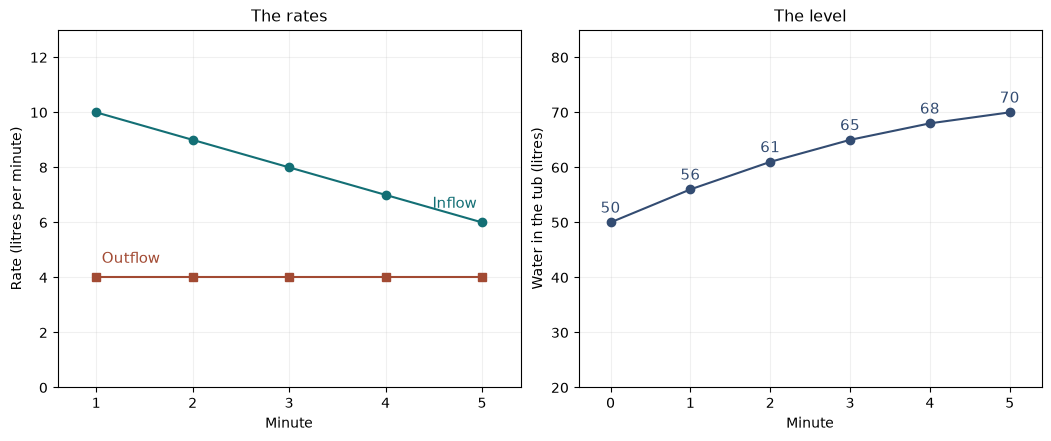

- **Inflow direction:** falling every minute
- **Net flow by minute (l/min):** 6, 5, 4, 3, 2
- **Level after 5 minutes (l):** 70
- **Change in level (l):** 20

Each minute adds inflow minus outflow. The net flows are 6 + 5 + 4 + 3 + 2, so the level is 50 + 6 + 5 + 4 + 3 + 2 = 70 litres. The tub gained water, by 20 litres, while the inflow was falling. The direction of the level follows the sign of the net flow, not the direction of either rate.

In [6]:
show(rate_versus_level(inflow_shape='falling', outflow=4.0))

**Use the idea.** Before reading a headline about a rate as news about a level, write the other flow and the starting level next to it and add up the net flows.

**Where the conclusion applies.** Five one-minute steps, constant rates within each minute, a 50 litre start, and no floor. The conclusion fails if an unlisted flow also moves the stock.

*Constructed example: the chapter's own five-minute tables, recomputed with the chapter's integrate function.*

Every setting the interactive reader offers for this demonstration:

In [7]:
sweep(rate_versus_level, [('inflow_shape', ['falling', 'rising']), ('outflow', [4.0, 6.0, 8.0, 9.0])])

- **inflow_shape = falling, outflow = 4.0**: Inflow direction falling every minute; Net flow by minute (l/min) 6, 5, 4, 3, 2; Level after 5 minutes (l) 70; Change in level (l) 20
- **inflow_shape = falling, outflow = 6.0**: Inflow direction falling every minute; Net flow by minute (l/min) 4, 3, 2, 1, 0; Level after 5 minutes (l) 60; Change in level (l) 10
- **inflow_shape = falling, outflow = 8.0**: Inflow direction falling every minute; Net flow by minute (l/min) 2, 1, 0, (-1), (-2); Level after 5 minutes (l) 50; Change in level (l) 0
- **inflow_shape = falling, outflow = 9.0**: Inflow direction falling every minute; Net flow by minute (l/min) 1, 0, (-1), (-2), (-3); Level after 5 minutes (l) 45; Change in level (l) (-5)
- **inflow_shape = rising, outflow = 4.0**: Inflow direction rising every minute; Net flow by minute (l/min) 1, 2, 3, 4, 5; Level after 5 minutes (l) 65; Change in level (l) 15
- **inflow_shape = rising, outflow = 6.0**: Inflow direction rising every minute; Net flow by minute (l/min) (-1), 0, 1, 2, 3; Level after 5 minutes (l) 55; Change in level (l) 5
- **inflow_shape = rising, outflow = 8.0**: Inflow direction rising every minute; Net flow by minute (l/min) (-3), (-2), (-1), 0, 1; Level after 5 minutes (l) 45; Change in level (l) (-5)
- **inflow_shape = rising, outflow = 9.0**: Inflow direction rising every minute; Net flow by minute (l/min) (-4), (-3), (-2), (-1), 0; Level after 5 minutes (l) 40; Change in level (l) (-10)

## 2. The step length turns a rate into an amount

*What goes wrong if dt is left out of the update?*

Kept, dt scales each step so that five minutes always add 30 litres. Dropped, every step adds the full rate, so more, shorter steps add more water and the answer depends on the step length.

    stock(t + dt) = stock(t) + dt * (inflow - outflow)

**Symbols and inputs.** dt is the step length in minutes. inflow is 10 and outflow 4 litres per minute, so the net flow is 6 litres per minute; dt x 6 is litres.

**Predict first.** If the step shrinks to a quarter minute and dt is dropped, how many litres does the tub show after five minutes?

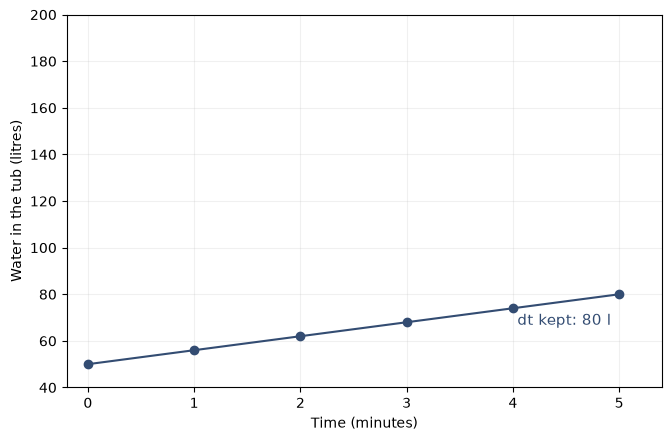

- **Step length dt (minutes):** 1.00
- **Steps in 5 minutes:** 5
- **Litres added per step:** 6.0
- **Level after 5 minutes (l):** 80

With dt = 1.00, each step adds 1.00 x (10 - 4) = 6.0 litres. 5 steps x 6.0 = 30, so the tub ends at 50 + 30 = 80 litres whatever the step length.

In [8]:
show(step_length(dt=1.0, keep_dt='kept'))

**Use the idea.** Check that every term added to a stock carries the stock's units, which is the cheapest unit test a model has.

**Where the conclusion applies.** Constant rates for five minutes from 50 litres. With changing rates a long step also adds integration error, the subject of Chapter 19.

*Constructed example: rates from the chapter's first table, advanced with the chapter's advance_stock function.*

Every setting the interactive reader offers for this demonstration:

In [9]:
sweep(step_length, [('dt', [1.0, 0.5, 0.25]), ('keep_dt', ['kept', 'dropped'])])

- **dt = 1.0, keep_dt = kept**: Step length dt (minutes) 1.00; Steps in 5 minutes 5; Litres added per step 6.0; Level after 5 minutes (l) 80
- **dt = 1.0, keep_dt = dropped**: Step length dt (minutes) 1.00; Steps in 5 minutes 5; Litres added per step 6.0; Level after 5 minutes (l) 80
- **dt = 0.5, keep_dt = kept**: Step length dt (minutes) 0.50; Steps in 5 minutes 10; Litres added per step 3.0; Level after 5 minutes (l) 80
- **dt = 0.5, keep_dt = dropped**: Step length dt (minutes) 0.50; Steps in 5 minutes 10; Litres added per step 6.0; Level after 5 minutes (l) 110
- **dt = 0.25, keep_dt = kept**: Step length dt (minutes) 0.25; Steps in 5 minutes 20; Litres added per step 1.5; Level after 5 minutes (l) 80
- **dt = 0.25, keep_dt = dropped**: Step length dt (minutes) 0.25; Steps in 5 minutes 20; Litres added per step 6.0; Level after 5 minutes (l) 170

## 3. Read every flow, then write every stock

*When tub A drains into tub B, does the update order change the answer?*

Computing the flow from the state at time t moves the same litres out of A and into B. Updating A first lets B see a level that does not exist yet, so B receives less than A lost.

    stock(t + dt) = stock(t) + dt * (inflow - outflow)

**Symbols and inputs.** A and B are litres in each tub. A drains a fixed fraction of its level per step, and that flow is B's inflow. One step, dt = 1.

**Predict first.** If A is updated first and B's inflow is read from A's new level, does the total water stay at 100 litres?

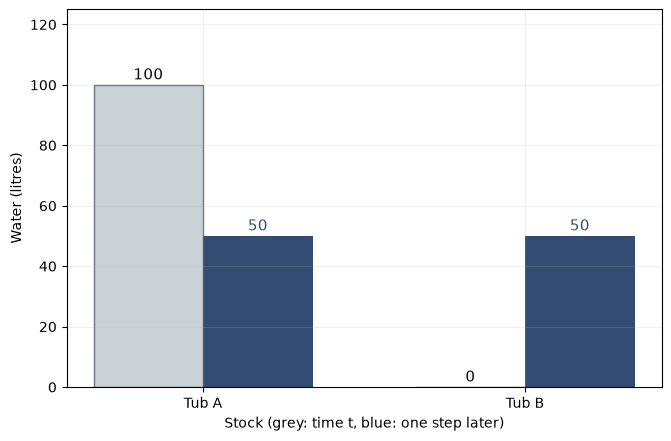

- **Update order:** flows first
- **Flow out of A (l):** 50
- **Flow into B (l):** 50
- **A + B after one step (l):** 100
- **Water created or lost (l):** 0

Read the flow from A at time t: 0.5 x 100 = 50 litres. Then A = 100 - 50 = 50 and B = 0 + 50 = 50. Together 100 litres, the same 100 the step began with.

In [10]:
show(two_tubs(drain_fraction=0.5, order='flows first'))

**Use the idea.** In any multi-stock model, compute every flow from the old state before writing any stock.

**Where the conclusion applies.** Two stocks, a drain proportional to A's level, a 100 litre start in A and an empty B. A step too long for that rule calls for a shorter step, not a different order.

*Constructed example: the two-tub structure from the chapter, with the drain fraction defined for this reader.*

Every setting the interactive reader offers for this demonstration:

In [11]:
sweep(two_tubs, [('drain_fraction', [0.3, 0.5, 0.8]), ('order', ['flows first', 'A first'])])

- **drain_fraction = 0.3, order = flows first**: Update order flows first; Flow out of A (l) 30; Flow into B (l) 30; A + B after one step (l) 100; Water created or lost (l) 0
- **drain_fraction = 0.3, order = A first**: Update order A first; Flow out of A (l) 30; Flow into B (l) 21; A + B after one step (l) 91; Water created or lost (l) (-9)
- **drain_fraction = 0.5, order = flows first**: Update order flows first; Flow out of A (l) 50; Flow into B (l) 50; A + B after one step (l) 100; Water created or lost (l) 0
- **drain_fraction = 0.5, order = A first**: Update order A first; Flow out of A (l) 50; Flow into B (l) 25; A + B after one step (l) 75; Water created or lost (l) (-25)
- **drain_fraction = 0.8, order = flows first**: Update order flows first; Flow out of A (l) 80; Flow into B (l) 80; A + B after one step (l) 100; Water created or lost (l) 0
- **drain_fraction = 0.8, order = A first**: Update order A first; Flow out of A (l) 80; Flow into B (l) 16; A + B after one step (l) 36; Water created or lost (l) (-64)

## 4. A floor is a claim, and conservation can see it

*What does holding a stock at zero do to the conservation check?*

Without a floor the stock goes negative and the records agree. With a floor, the path stops at zero while the flows keep recording a deficit, and the gap appears as a positive residual.

    stock(t + dt) = stock(t) + dt * (inflow - outflow)

**Symbols and inputs.** The stock starts at 10. The inflow is 5 per minute and the outflow is chosen. apply_floor holds the stock at zero; the conservation residual is the change in the stock minus the accumulated net flow.

**Predict first.** With the outflow at 12 and the floor applied, is the conservation residual zero, positive or negative?

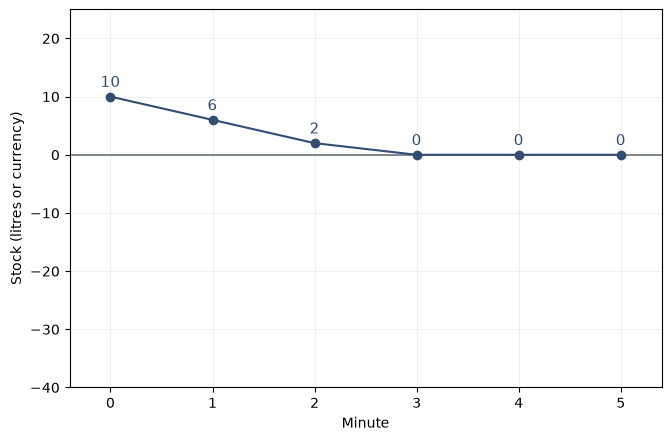

- **Floor at zero:** applied
- **Net flow per minute:** (-4)
- **Stock after 5 minutes:** 0
- **Conservation residual:** 10

The flows say the stock should change by 5 x (5 - 9) = (-20). The path changed by 0 - 10 = (-10). Residual = (-10) - (-20) = 10. The floor removed a deficit the flows still record, so a reader who checks conservation finds it.

In [12]:
show(floor_claim(outflow=9.0, floor='applied'))

**Use the idea.** A floor suits a tank or a workforce, not an account with an overdraft. Writing it in the model makes the claim checkable.

**Where the conclusion applies.** Five one-minute steps with constant flows. A residual here comes from the floor alone; in real records it can also come from unreported transfers or definition changes.

*Constructed example: values defined for this reader, run through the chapter's apply_floor and conservation_error functions.*

Every setting the interactive reader offers for this demonstration:

In [13]:
sweep(floor_claim, [('outflow', [6.0, 9.0, 12.0]), ('floor', ['applied', 'not applied'])])

- **outflow = 6.0, floor = applied**: Floor at zero applied; Net flow per minute (-1); Stock after 5 minutes 5; Conservation residual 0
- **outflow = 6.0, floor = not applied**: Floor at zero not applied; Net flow per minute (-1); Stock after 5 minutes 5; Conservation residual 0
- **outflow = 9.0, floor = applied**: Floor at zero applied; Net flow per minute (-4); Stock after 5 minutes 0; Conservation residual 10
- **outflow = 9.0, floor = not applied**: Floor at zero not applied; Net flow per minute (-4); Stock after 5 minutes -10; Conservation residual 0
- **outflow = 12.0, floor = applied**: Floor at zero applied; Net flow per minute (-7); Stock after 5 minutes 0; Conservation residual 25
- **outflow = 12.0, floor = not applied**: Floor at zero not applied; Net flow per minute (-7); Stock after 5 minutes -25; Conservation residual 0

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

With the inflow rising 5, 6, 7, 8, 9 and the outflow at 9, what is the level after five minutes?

<details><summary>Answer</summary>

Net flows -4, -3, -2, -1, 0 sum to -10, so the level is 50 - 10 = 40 litres, as the chapter's mirror table shows.

</details>

### Exercise 2

With dt = 0.5 kept, how many litres does each step add, and how many steps fit in five minutes?

<details><summary>Answer</summary>

0.5 x 6 = 3 litres per step, and 5 / 0.5 = 10 steps, so 10 x 3 = 30 litres, ending at 80.

</details>

### Exercise 3

With a drain fraction of 0.8 and A updated first, how much water disappears in one step?

<details><summary>Answer</summary>

A falls to 20, B receives 0.8 x 20 = 16, so 100 - (20 + 16) = 64 litres disappear.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/